# End-to-End ML Pipeline — Tesla Deliveries & Production Data (2015–2025)

**Dataset:** [Kaggle](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

Pipeline: Data Loading → Cleaning → EDA → Feature Engineering → Preprocessing → Regression → CV → Hyperparameter Tuning → Time Series Forecasting

## 1. Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading

In [10]:
path = '/kaggle/input/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'

from google.colab import files
uploaded = files.upload()
import io
path = io.BytesIO(list(uploaded.values())[0])

df = pd.read_csv(path)
print(df.shape)
df.head()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv
(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [12]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 3. Data Cleaning

In [13]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [14]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)

(2640, 12)


In [16]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)
# df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
print(df[['Date', 'Year', 'Month', 'Quarter']].head())
print("\nNew Data Types:")
df.dtypes

        Date  Year  Month  Quarter
0 2015-01-01  2015      1        1
1 2015-01-01  2015      1        1
2 2015-01-01  2015      1        1
3 2015-01-01  2015      1        1
4 2015-01-01  2015      1        1

New Data Types:


,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


In [20]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[c] >= q1 - 1.5*iqr) & (df[c] <= q3 + 1.5*iqr)]
df.rename(columns={
    'Estimated_Deliveries': 'Total Deliveries',
    'Production_Units': 'Total Production'
}, inplace=True)
print("Updated Columns:", df.columns.tolist())
df.reset_index(drop=True, inplace=True)
print(df.shape)

Updated Columns: ['Year', 'Month', 'Region', 'Model', 'Total Deliveries', 'Total Production', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Quarter']
(2571, 14)


## 4. Exploratory Data Analysis

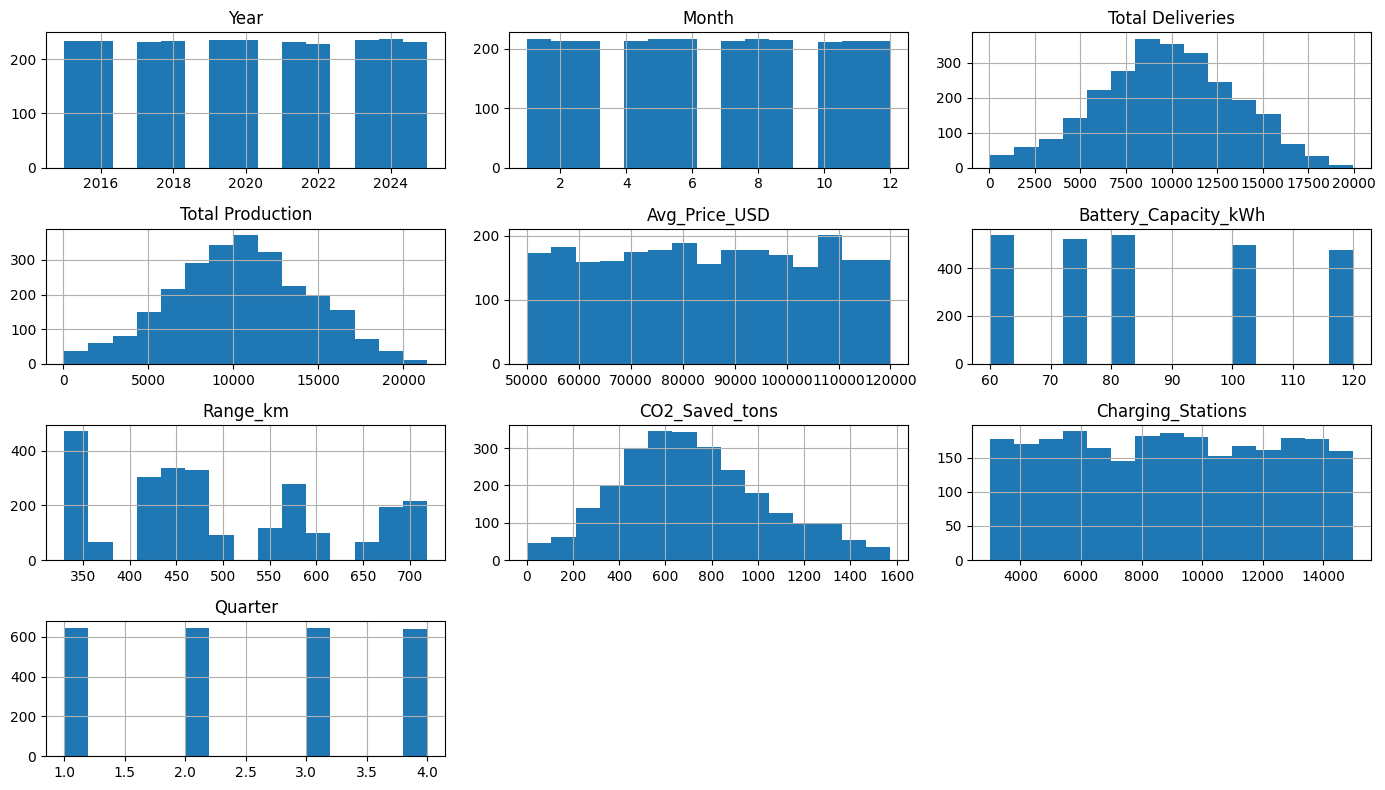

In [22]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(bins=15, figsize=(14, 8))
plt.tight_layout()
plt.show()

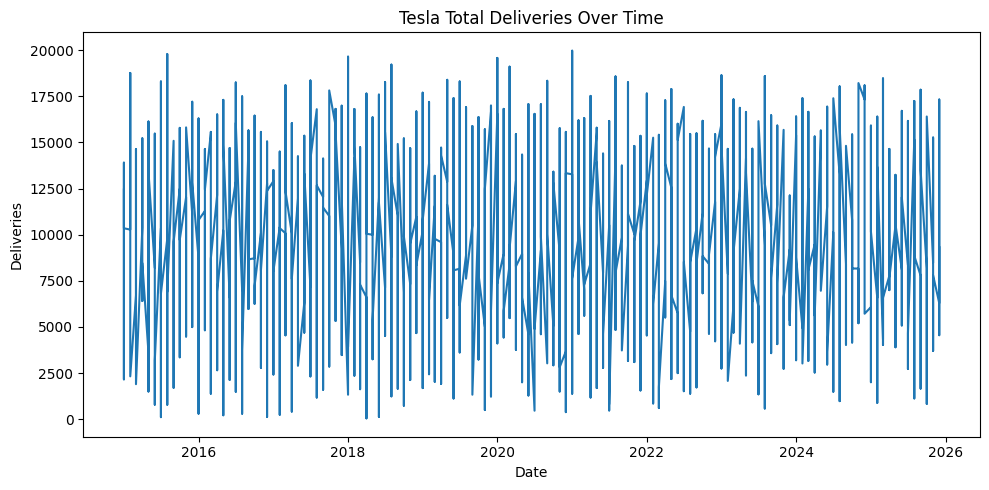

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Total Deliveries'])
plt.title('Tesla Total Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

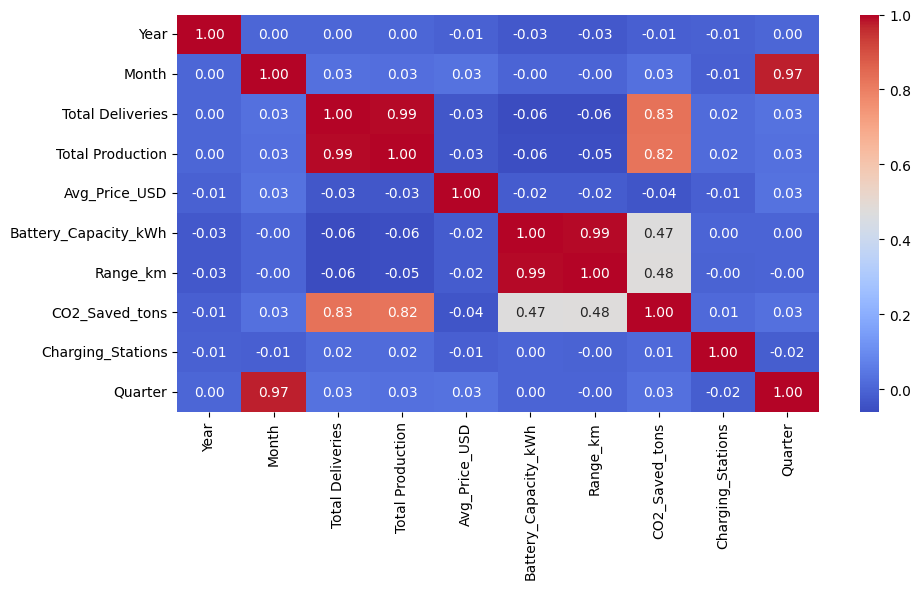

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

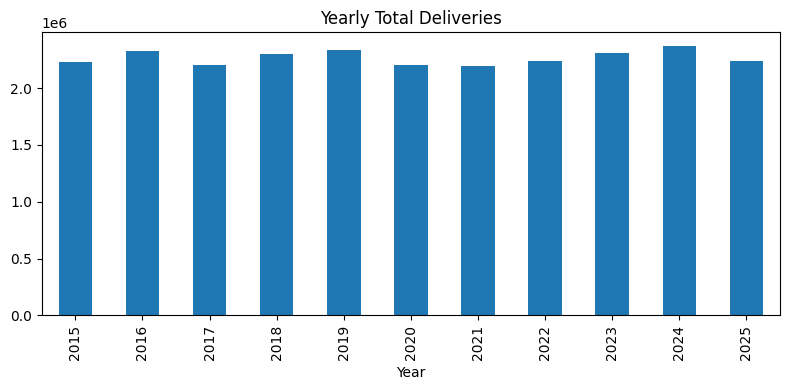

In [25]:
plt.figure(figsize=(8, 4))
df.groupby('Year')['Total Deliveries'].sum().plot(kind='bar')
plt.title('Yearly Total Deliveries')
plt.tight_layout()
plt.show()

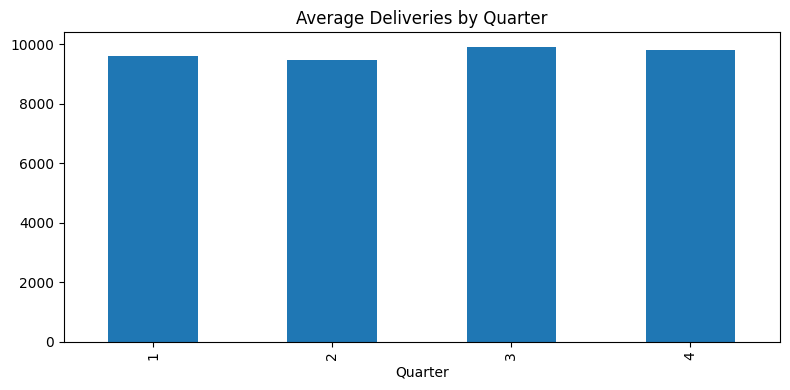

In [26]:
plt.figure(figsize=(8, 4))
df.groupby('Quarter')['Total Deliveries'].mean().plot(kind='bar')
plt.title('Average Deliveries by Quarter')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [27]:
df['lag_1'] = df['Total Deliveries'].shift(1)
df['lag_2'] = df['Total Deliveries'].shift(2)
df['lag_3'] = df['Total Deliveries'].shift(3)
df['rolling_mean_3'] = df['Total Deliveries'].rolling(3).mean()
df['rolling_std_3'] = df['Total Deliveries'].rolling(3).std()
df['delivery_rate'] = df['Total Deliveries'] / df['Total Production']
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)

(2568, 20)


## 6. Encoding & Scaling

In [28]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.shape

(2568, 26)

In [29]:
target = 'Total Deliveries'
drop_cols = ['Date', target]
feat_cols = [c for c in df.columns if c not in drop_cols]

X = df[feat_cols].values
y = df[target].values

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train.shape, X_test.shape)

(2054, 24) (514, 24)


## 7. Chronological Split & Data Leakage

Train/test split preserves temporal order (80/20). Lag features reference only past values — no future information leaks into training.

## 8. Bias-Variance Tradeoff

- High bias = underfitting (too simple)
- High variance = overfitting (memorises training data)
- Ridge/Lasso regularisation penalises large coefficients to reduce variance
- TimeSeriesSplit CV estimates generalisation error

## 9. Regression Models

In [30]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae  = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2   = r2_score(yte, pred)
    print(f"{name:<20} MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}")
    return pred

lr_pred  = evaluate('Linear Regression', LinearRegression(), X_train, y_train, X_test, y_test)
rr_pred  = evaluate('Ridge',             Ridge(alpha=1.0),   X_train, y_train, X_test, y_test)
las_pred = evaluate('Lasso',             Lasso(alpha=1.0),   X_train, y_train, X_test, y_test)

Linear Regression    MAE=0  RMSE=0  R2=1.0000
Ridge                MAE=57  RMSE=81  R2=0.9995
Lasso                MAE=81  RMSE=116  R2=0.9989


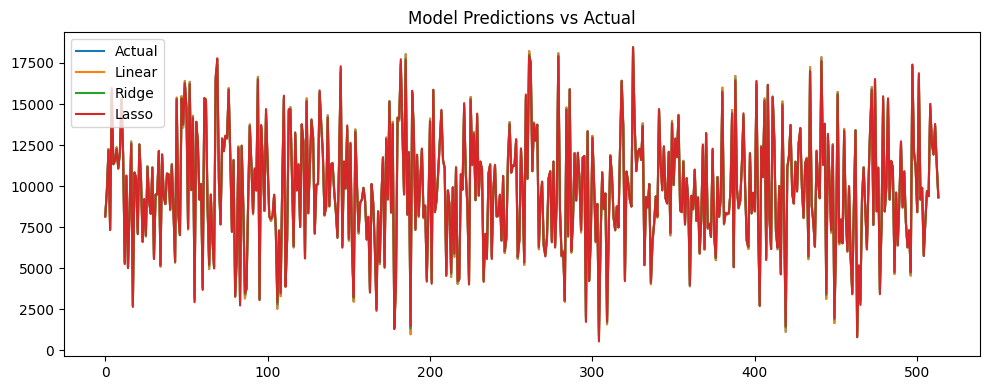

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(y_test,   label='Actual')
plt.plot(lr_pred,  label='Linear')
plt.plot(rr_pred,  label='Ridge')
plt.plot(las_pred, label='Lasso')
plt.legend()
plt.title('Model Predictions vs Actual')
plt.tight_layout()
plt.show()

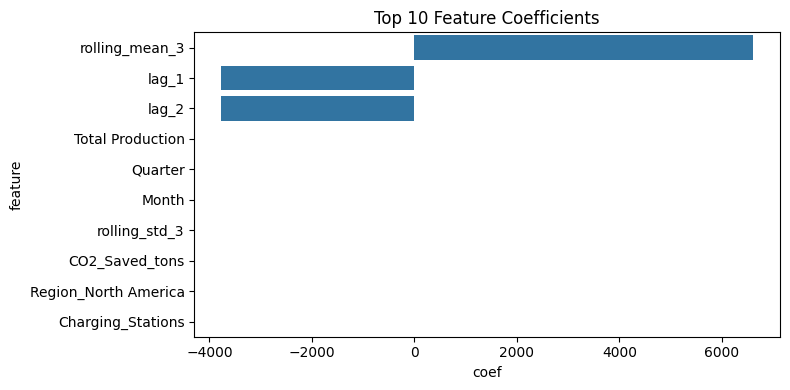

In [32]:
lr = LinearRegression().fit(X_train, y_train)
coef_df = pd.DataFrame({'feature': feat_cols, 'coef': lr.coef_})
coef_df = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index)
plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df.head(10), x='coef', y='feature')
plt.title('Top 10 Feature Coefficients')
plt.tight_layout()
plt.show()

## 10. Cross Validation (TimeSeriesSplit)

In [33]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for tr_idx, val_idx in tscv.split(X_train):
    Xtr_, Xval_ = X_train[tr_idx], X_train[val_idx]
    ytr_, yval_ = y_train[tr_idx], y_train[val_idx]
    m = Ridge(alpha=1.0)
    m.fit(Xtr_, ytr_)
    cv_scores.append(r2_score(yval_, m.predict(Xval_)))

print(f"CV R2 scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean R2      : {np.mean(cv_scores):.4f}  Std: {np.std(cv_scores):.4f}")

CV R2 scores : [0.9989, 0.9991, 0.9994, 0.9994, 0.9996]
Mean R2      : 0.9993  Std: 0.0002


## 11. Hyperparameter Tuning — Ridge

In [34]:
grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.01, 0.1, 1.0, 10, 100]},
    cv=tscv,
    scoring='r2'
)
grid.fit(X_train, y_train)
print('Best alpha:', grid.best_params_)
print('Best CV R2:', round(grid.best_score_, 4))

Best alpha: {'alpha': 0.01}
Best CV R2: 1.0


In [35]:
best_ridge = grid.best_estimator_
final_pred = best_ridge.predict(X_test)
print(f"Test MAE  : {mean_absolute_error(y_test, final_pred):,.0f}")
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, final_pred)):,.0f}")
print(f"Test R2   : {r2_score(y_test, final_pred):.4f}")

Test MAE  : 2
Test RMSE : 2
Test R2   : 1.0000


## 12. Hyperparameter Tuning — Lasso

In [36]:
lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1.0, 10]},
    cv=tscv,
    scoring='r2'
)
lasso_grid.fit(X_train, y_train)
print('Best alpha:', lasso_grid.best_params_)
lp = lasso_grid.best_estimator_.predict(X_test)
print(f"Lasso Test R2: {r2_score(y_test, lp):.4f}")

Best alpha: {'alpha': 0.001}
Lasso Test R2: 1.0000


## 13. Time Series Analysis & Forecasting

### 13.1 Decomposition

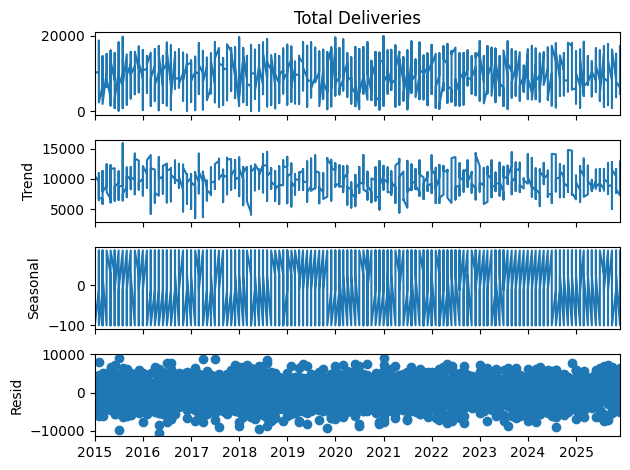

In [37]:
ts = df.set_index('Date')['Total Deliveries']
result = seasonal_decompose(ts, model='additive', period=4)
result.plot()
plt.tight_layout()
plt.show()

### 13.2 Stationarity — ADF Test

In [38]:
adf_stat, p_val, *_ = adfuller(ts)
print(f'ADF Statistic : {adf_stat:.4f}')
print(f'p-value       : {p_val:.4f}')
print('Stationary' if p_val < 0.05 else 'Non-stationary')

ADF Statistic : -27.3998
p-value       : 0.0000
Stationary


In [39]:
ts_diff = ts.diff().dropna()
adf2, p2, *_ = adfuller(ts_diff)
print(f'After differencing — p-value: {p2:.4f}')
print('Stationary' if p2 < 0.05 else 'Non-stationary')

After differencing — p-value: 0.0000
Stationary


### 13.3 SARIMA Forecasting

In [40]:
train_ts = ts.iloc[:-4]
test_ts  = ts.iloc[-4:]

sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,0,4))
sarima_fit = sarima.fit(disp=False)
sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                   Total Deliveries   No. Observations:                 2564
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 4)   Log Likelihood              -25208.916
Date:                            Sun, 07 Jun 2026   AIC                          50425.832
Time:                                    19:09:02   BIC                          50449.222
Sample:                                         0   HQIC                         50434.314
                                           - 2564                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0101      0.020     -0.497      0.619      -0.050       0.030
ma.L1         -1.0000      0.029    -34.255      0.000      -1.057      -0.943
ar.S.L4       -0.4892      0.018    -26.953      0.000      -0.525      -0.454
sigma2      2.101e+07   1.39e-09   1.51e+16      0.000     2.1e+07     2.1e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.08
Prob(Q):                              0.97   Prob(JB):                         0.21
Heteroskedasticity (H):               0.90   Skew:                            -0.02
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.51e+30. Standard errors may be unstable.
"""

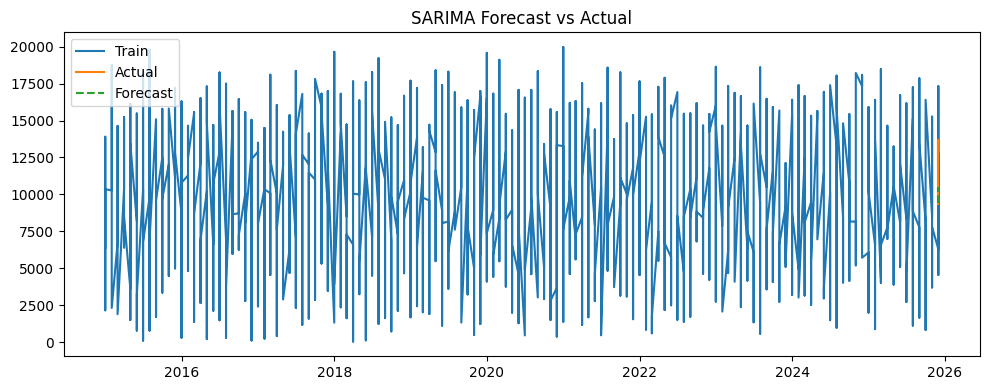

Forecast MAE  : 2,133
Forecast RMSE : 2,476
Forecast R2   : -1.5340


In [41]:
forecast = sarima_fit.forecast(steps=4)

plt.figure(figsize=(10, 4))
plt.plot(train_ts.index, train_ts, label='Train')
plt.plot(test_ts.index,  test_ts,  label='Actual')
plt.plot(test_ts.index,  forecast, label='Forecast', linestyle='--')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.tight_layout()
plt.show()

print(f"Forecast MAE  : {mean_absolute_error(test_ts, forecast):,.0f}")
print(f"Forecast RMSE : {np.sqrt(mean_squared_error(test_ts, forecast)):,.0f}")
print(f"Forecast R2   : {r2_score(test_ts, forecast):.4f}")

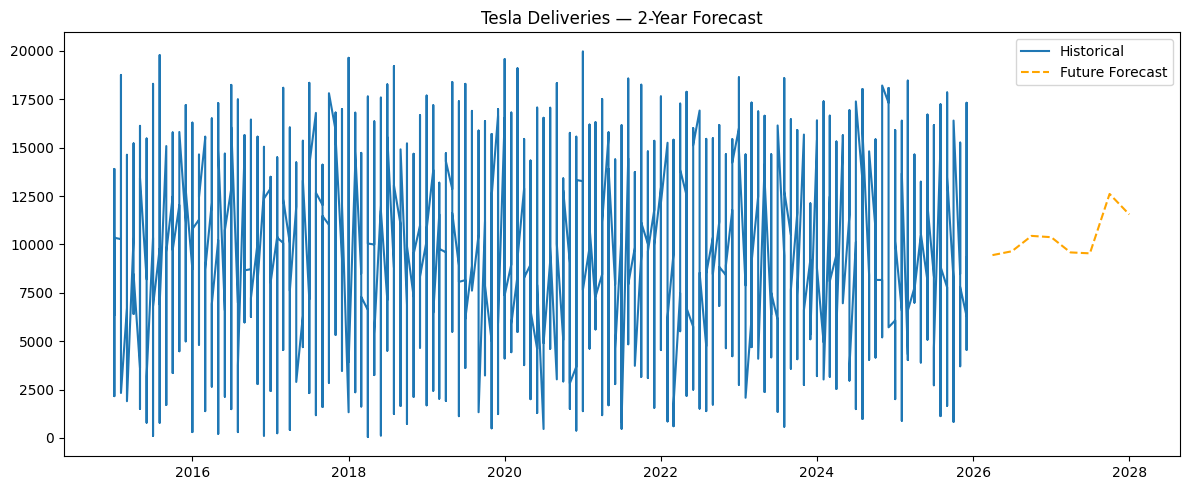

In [42]:
future_fc  = sarima_fit.forecast(steps=8)
last_date  = ts.index[-1]
fut_dates  = pd.date_range(start=last_date, periods=9, freq='QS')[1:]

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts, label='Historical')
plt.plot(fut_dates, future_fc, label='Future Forecast', linestyle='--', color='orange')
plt.legend()
plt.title('Tesla Deliveries — 2-Year Forecast')
plt.tight_layout()
plt.show()

## 14. Model Comparison

In [43]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (tuned)':     grid.best_estimator_,
    'Lasso (tuned)':     lasso_grid.best_estimator_
}

rows = []
for name, m in models.items():
    if name == 'Linear Regression':
        m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test, p), 2),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, p)), 2),
        'R2':    round(r2_score(y_test, p), 4)
    })

pd.DataFrame(rows)

,Model,MAE,RMSE,R2
0,Linear Regression,0.00,0.00,1.0
1,Ridge (tuned),1.64,2.35,1.0
2,Lasso (tuned),17.07,24.48,1.0
